In [485]:
# Imports for the project
import itertools
from sklearn.model_selection import cross_val_score
from sklearn import linear_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

The findsubsets functionwhich is useful for phase 6 when we will be finding the bes subset of features to train  a linear regression model to compare with the Ridge and LASSO models.

In [486]:
def findsubsets(S,k):
    return set(itertools.combinations(S, k))

This project is seperated into 6 phases with the first five phases looking at
looking at the indivual features of a graph and then plotting them agaist the crossing number of the graph. We also use the graph to make linear regressions with each indivual features. The 6th phase is when we put all of the other 5 phases and combine them to make a linear regression that caan predict the crossing number of a given graph. Also for each feature we will normalize  them by dividing them by their maximum values (explained in Appendix D)

Phase 1: Comparing the crossings number to Edges

In this phase we will be comparing the crossing number of a graph with the
number of nodes and edges

In [487]:
phase1_train = pd.read_csv('../data/phase1Train')

# Getting training features and target
phase1_train_X = phase1_train[['nodes','edges']]
phase1_train_Y = phase1_train['crossings']


First we going to graph the edges to the crossings of the training data to get an idea how each interact with each other.

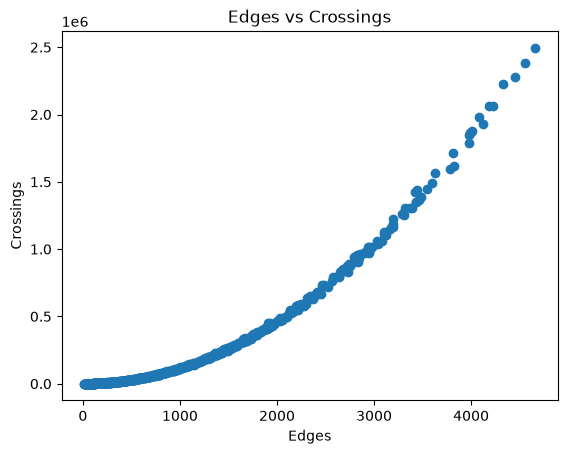

In [488]:
plt.title("Edges vs Crossings")
plt.xlabel("Edges")
plt.ylabel("Crossings")
plt.scatter(phase1_train_X['edges'], phase1_train_Y)
plt.savefig('../figures/graph1.png')

Now the graph above looks like a highly correlated but non-linear correlation between the edges and crossings.

Squaring edges and then plotting them agaist crossings (should be linear).

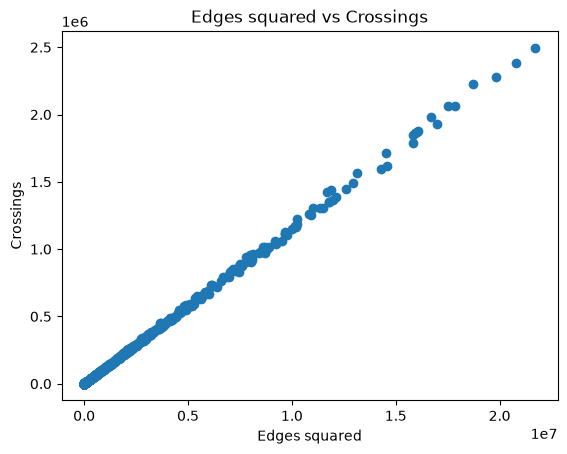

In [489]:
phase1_train_X.loc[:, 'edges'] = np.power(phase1_train_X['edges'], 2)
plt.title("Edges squared vs Crossings")
plt.xlabel("Edges squared")
plt.ylabel("Crossings")
plt.scatter(phase1_train_X['edges'], phase1_train_Y)
plt.savefig('../figures/graph2.png')

Now we going to plot nodes agaist the crossings.

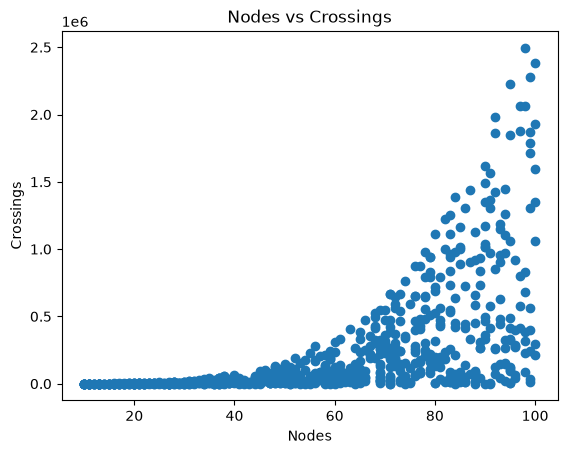

In [490]:
plt.title("Nodes vs Crossings")
plt.xlabel("Nodes")
plt.ylabel("Crossings")
plt.scatter(phase1_train_X['nodes'], phase1_train_Y)
plt.savefig('../figures/graph3.png')

Now Adding edges as a color gradient

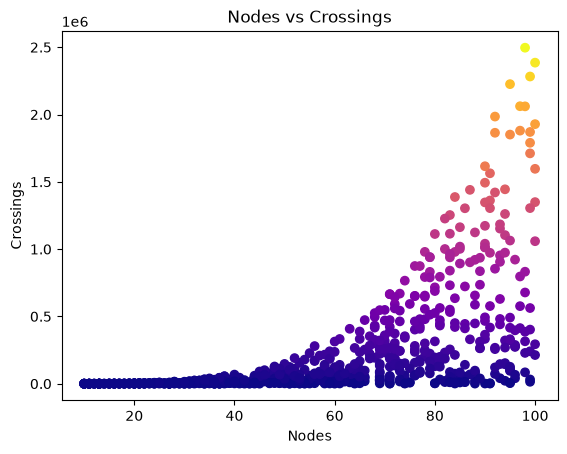

In [491]:
plt.title("Nodes vs Crossings")
plt.xlabel("Nodes")
plt.ylabel("Crossings")
plt.scatter(phase1_train_X['nodes'], phase1_train_Y, c=phase1_train_X['edges'], cmap='plasma')
plt.savefig('../figures/graph4.png')

As we can clearly see above that gradient changes  color (meaning more  edges) as we go up and the max  edges are around the square of the nodes so we will put nodes to  the fourth power.

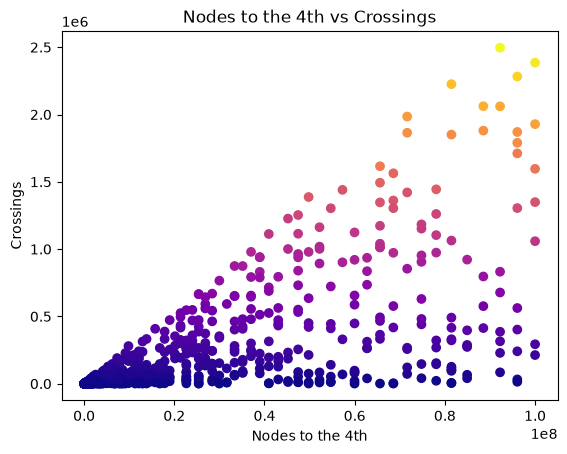

In [492]:
phase1_train_X.loc[:, 'nodes'] = np.power(phase1_train_X['nodes'], 4)
plt.title("Nodes to the 4th vs Crossings")
plt.xlabel("Nodes to the 4th")
plt.ylabel("Crossings")
plt.scatter(phase1_train_X['nodes'], phase1_train_Y, c=phase1_train_X['edges'], cmap='plasma')
plt.savefig('../figures/graph5.png')

Now the maximum crossing number given n nodes show be a linear line.

Now we will train a linear regression with the method of least squares using sklearn's LinearRegression model.

In [493]:
phase1_regression = linear_model.LinearRegression()
phase1_regression.fit(phase1_train_X, phase1_train_Y)

print("R^2 =", phase1_regression.score(phase1_train_X, phase1_train_Y))

R^2 = 0.9994308374126252


Since the R^2 is around 1 ( as seen above from the edges) we can say on the training  data that this is a good linear regression on the data. Now we will try it on the testing data.

In [494]:
phase1_test = pd.read_csv('../data/phase1Test')

# Getting training features and target
phase1_test_X = phase1_test[['nodes','edges']]
phase1_test_Y = phase1_test['crossings']

phase1_test_X.loc[:, 'edges'] = np.power(phase1_test_X['edges'], 2)
phase1_test_X.loc[:, 'nodes'] = np.power(phase1_test_X['nodes'], 4)

In [495]:
print("R^2 =", phase1_regression.score(phase1_test_X, phase1_test_Y))

R^2 = 0.9994891273300034


Again we get R^2 to be around 1 so for only having two features we can get a good linear regression of edges squared and nodes to the fourth power with the given coefficients.

In [496]:
print("Nodes coefficient = ", phase1_regression.coef_[0])
print("Edges coefficient = ", phase1_regression.coef_[1])

Nodes coefficient =  -1.0770758429240186e-05
Edges coefficient =  0.11584033000522438


Phase 2: How Crossings Change with the Min\Max distance

In this phase we going see if the minimum or maximum distance between edges affect the crossings or maybe a combination between them

In [497]:
phase2_train = pd.read_csv('../data/phase2Train')

# Getting training features and target
phase2_train_X = phase2_train[['minimum distance','maximum distance']]
phase2_train_Y = phase2_train['crossings']

First we going to plot minimum distance and crossings

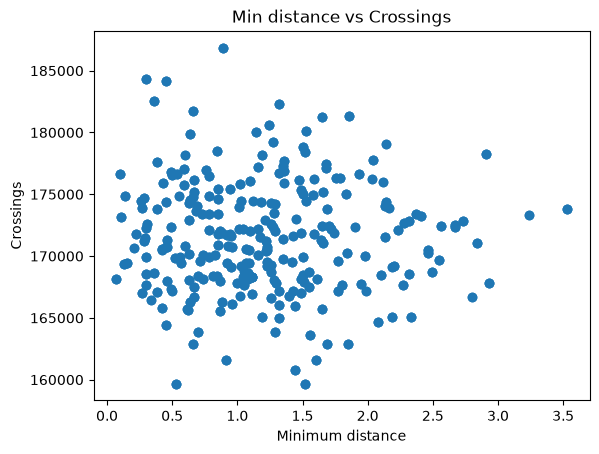

In [498]:
plt.title("Min distance vs Crossings")
plt.xlabel("Minimum distance")
plt.ylabel("Crossings")
plt.scatter(phase2_train_X['minimum distance'], phase2_train_Y)
plt.savefig('../figures/graph6.png')

Well compared to last phase where everything is well correlated and connected this phase is starting off differeent. So now let's look maximum distance and crossings

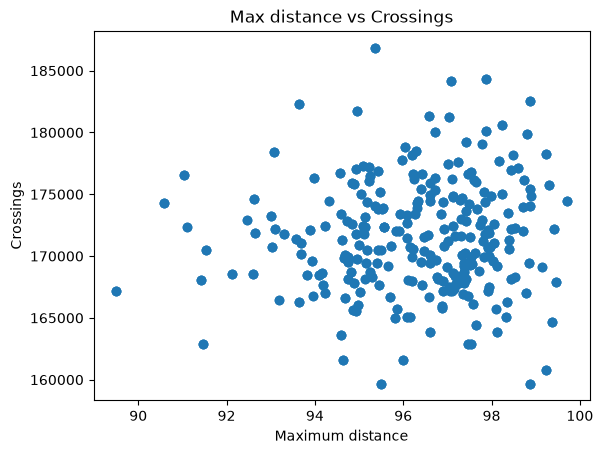

In [499]:
plt.title("Max distance vs Crossings")
plt.xlabel("Maximum distance")
plt.ylabel("Crossings")
plt.scatter(phase2_train_X['maximum distance'], phase2_train_Y)
plt.savefig('../figures/graph7.png')

Well that doesn't apper to have a correlation either so for one last time to try and get something that looks corellated we will subtract the max from the minimum

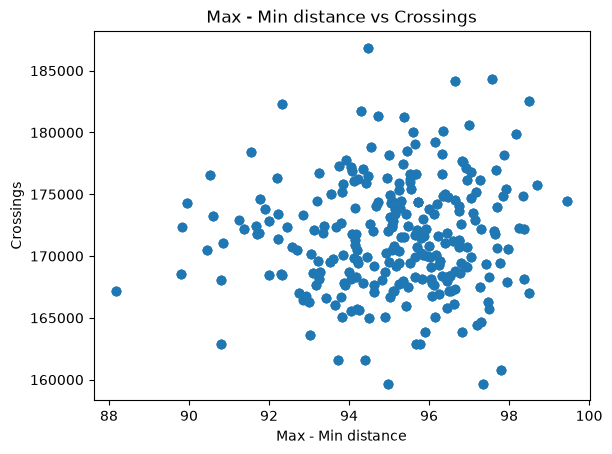

In [500]:
plt.title("Max - Min distance vs Crossings")
plt.xlabel("Max - Min distance")
plt.ylabel("Crossings")
plt.scatter(phase2_train_X['maximum distance'] - phase2_train_X['minimum distance'], phase2_train_Y)
plt.savefig('../figures/graph8.png')

Weel it loooks like we can't find a correlation so let's just go ahead and train the linear regression model with usings sklearn LinearRegression model.

In [501]:
phase2_regression = linear_model.LinearRegression()
phase2_regression.fit(phase2_train_X, phase2_train_Y)

print("R^2 =", phase2_regression.score(phase2_train_X, phase2_train_Y))

R^2 = 0.004278740073045628


As expected the R^2 is  very near 0 so it will probably not a feature that is very correlated with the crossings of a graph. Now let's test with testing data

In [502]:
phase2_test = pd.read_csv('../data/phase2Test')

# Getting training features and target
phase2_test_X = phase2_test[['minimum distance','maximum distance']]
phase2_test_Y = phase2_test['crossings']

In [503]:
print("R^2 =", phase2_regression.score(phase2_test_X, phase2_test_Y))

R^2 = 0.011253577541731175


And as expected the R^2 on the testing data is also below or near 0.

Phase 3: How Crossings change with Outer Radius

In this phase we will see if their is any correlation between the radius of the circle that the graph is contained in has any bearings on the crossings of the  graph.

In [504]:
phase3_train = pd.read_csv('../data/phase3Train')

# Getting training features and target
phase3_train_X = phase3_train['outer radius']
phase3_train_Y = phase3_train['crossings']

First we going to plot our outer radius vs the crossings

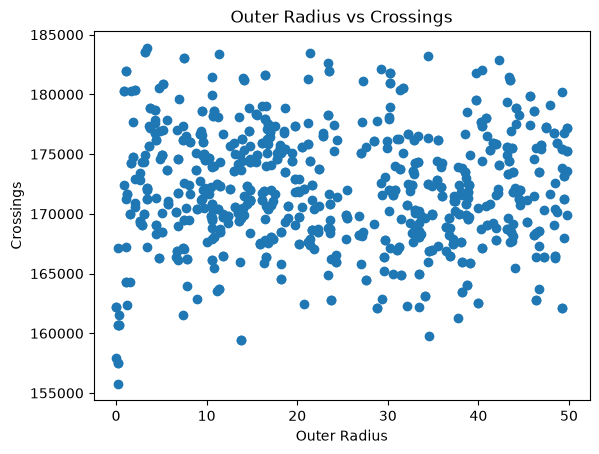

In [505]:
plt.title("Outer Radius vs Crossings")
plt.xlabel("Outer Radius")
plt.ylabel("Crossings")
plt.scatter(phase3_train_X, phase3_train_Y)
plt.savefig('../figures/graph9.png')

As the outer radius affects the  area of our graph we are going to square the outer radius just see if this affects the graph.

In [506]:
phase3_train_X= np.power(phase3_train_X, 2)

Now the graph for outer radius squared vs crossing number.

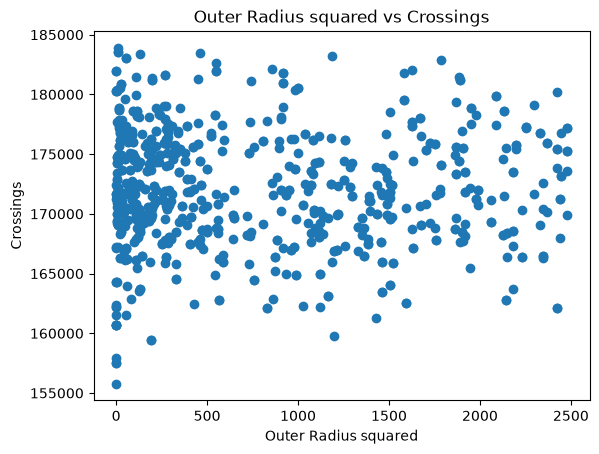

In [507]:
plt.title("Outer Radius squared vs Crossings")
plt.xlabel("Outer Radius squared")
plt.ylabel("Crossings")
plt.scatter(phase3_train_X, phase3_train_Y)
plt.savefig('../figures/graph10.png')

Same as last phase it seems like there is no correlationto this feature and the number of crossings in the graph. So, we are just going to make a linear regression and between the square of the outer radius and the crossing number

In [508]:
phase3_regression = linear_model.LinearRegression()
phase3_regression.fit(phase3_train_X.values.reshape(-1, 1), phase3_train_Y)

print("R^2 =", phase3_regression.score(phase3_train_X.values.reshape(-1, 1), phase3_train_Y))

R^2 = 0.0002127646020387841


Same as the last phase we can see that the correlation coefficient or R^2 is near 0 so we can say that there is no linear correlation between the outer radius and the crossing number. So let verify with the testing data.

In [509]:
phase3_test = pd.read_csv('../data/phase3Test')

# Getting training features and target
phase3_test_X = phase3_test['outer radius']
phase3_test_Y = phase3_test['crossings']

phase3_test_X= np.power(phase3_test_X, 2)

In [510]:
print("R^2 =", phase3_regression.score(phase3_test_X.values.reshape(-1, 1), phase3_test_Y))

R^2 = -0.11458795340684769


As we can verify with the testing data with the R^2 value being negative is that we have no correlation between outer radius aand the crossing number.

Phase 4: How Crossings changes with Innner radius

In this phase we will compare the crossing number with the inner radius of the annulus for the graph.

In [511]:
phase4_train = pd.read_csv('../data/phase4Train')

# Getting training features and target
phase4_train_X = phase4_train['inner radius']
phase4_train_Y = phase4_train['crossings']

First as we always do is to graph the feature (inner radius) with the the crossing number of the graph.

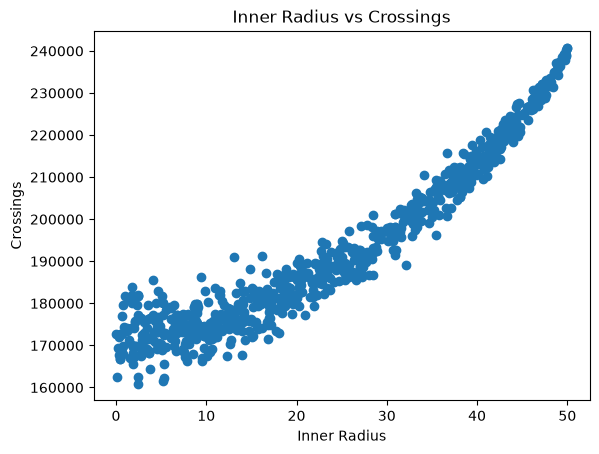

In [512]:
plt.title("Inner Radius vs Crossings")
plt.xlabel("Inner Radius")
plt.ylabel("Crossings")
plt.scatter(phase4_train_X, phase4_train_Y)
plt.savefig('../figures/graph11.png')

That is a nice looking horn-shaped graph with the crossing number being less varance as the inner radius increases which as the outer radius has an inneer radius 0 shows that the variance is great. But now we will square the inner radius as area can be the one thing that makes it curve.

In [513]:
phase4_train_X= np.power(phase4_train_X, 2)

Now we will graph the inner radius squared with the crossing number

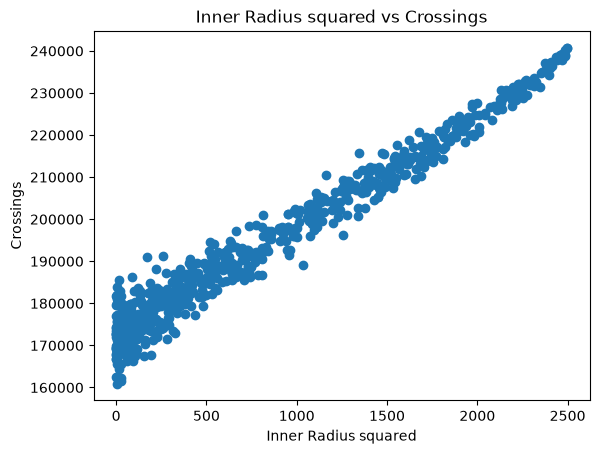

In [514]:
plt.title("Inner Radius squared vs Crossings")
plt.xlabel("Inner Radius squared")
plt.ylabel("Crossings")
plt.scatter(phase4_train_X, phase4_train_Y)
plt.savefig('../figures/graph12.png')

Now this looks more like a linear correlation that gets less varied as we increase the inner radius. SO now we will make  a linear regression model based on this.

In [515]:
phase4_regression = linear_model.LinearRegression()
phase4_regression.fit(phase4_train_X.values.reshape(-1, 1), phase4_train_Y)

print("R^2 =", phase4_regression.score(phase4_train_X.values.reshape(-1, 1), phase4_train_Y))

R^2 = 0.9658703916809884


I expected an high R^2  for this correlation but I did not  expect this  to be  this as high as .966 so let's use the test data to verify this regression.

In [516]:
phase4_test = pd.read_csv('../data/phase4Test')

# Getting training features and target
phase4_test_X = phase4_test['inner radius']
phase4_test_Y = phase4_test['crossings']

phase4_test_X = np.power(phase4_test_X, 2)

In [517]:
print("R^2 =", phase4_regression.score(phase4_test_X.values.reshape(-1, 1), phase4_test_Y))

R^2 = 0.968494116137299


As the R^2 for the testing data is .962 we can say that the inner radius sqaured is highly correlated the crossing number of a graph.

Phase 5: How Crossings change with Inner and Outer Radius

In phase 3 and 4 we looked at the outer and inner radius of the annulus on their own but now as we can see that in phase3

In [518]:
phase5_train = pd.read_csv('../data/phase5Train')

# Getting training features and target
phase5_train_X = phase5_train[['inner radius', 'outer radius']]
phase5_train_Y = phase5_train['crossings']

phase5_train_X = np.power(phase5_train_X, 2)

FIrst we will remake the Outer and  Inner radius plots

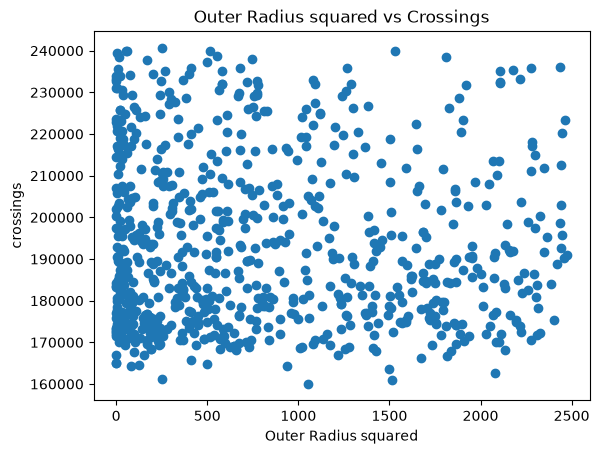

In [519]:
plt.title("Outer Radius squared vs Crossings")
plt.xlabel("Outer Radius squared")
plt.ylabel("crossings")
plt.scatter(phase5_train_X['outer radius'], phase5_train_Y)
plt.savefig('../figures/graph13.png')

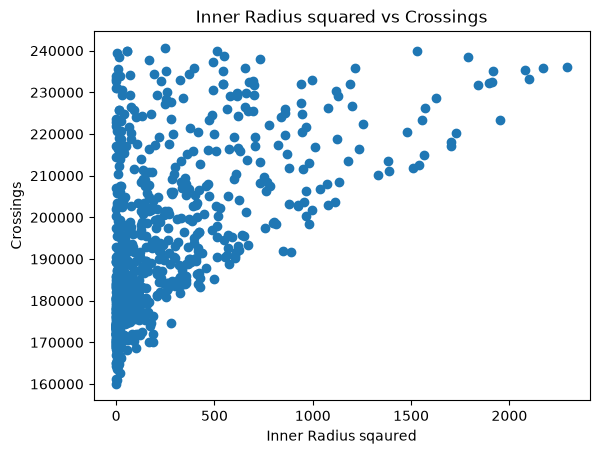

In [520]:
plt.title("Inner Radius squared vs Crossings")
plt.xlabel("Inner Radius sqaured")
plt.ylabel("Crossings")
plt.scatter(phase5_train_X['inner radius'], phase5_train_Y)
plt.savefig('../figures/graph14.png')

For the Outer radius graph it looks the same as the variance but for the Inner radius we can see that it has a minimum curve but has more variance. So, we going to plot it with the outer radius as the color mapping.

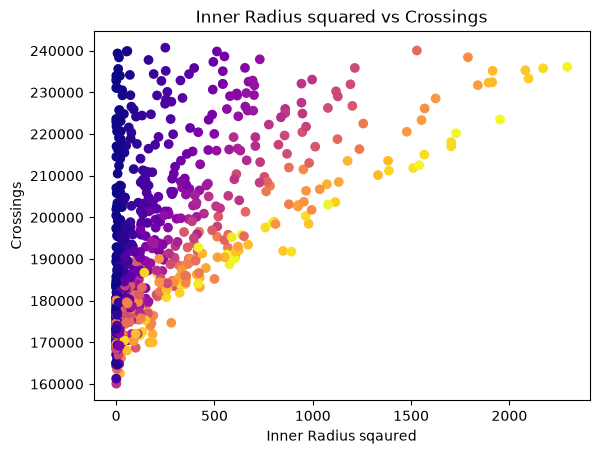

In [521]:
plt.title("Inner Radius squared vs Crossings")
plt.xlabel("Inner Radius sqaured")
plt.ylabel("Crossings")
plt.scatter(phase5_train_X['inner radius'], phase5_train_Y, c=phase5_train_X['outer radius'], cmap='plasma')
plt.savefig('../figures/graph15.png')

As we can see they are striped as the minimum is yellow to upper is purple. Now we are going to plot the subtracction of outer radius  to the inner radius.

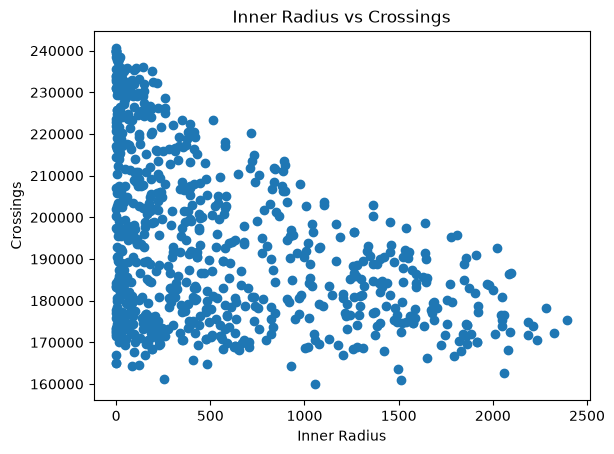

In [522]:
plt.title("Inner Radius vs Crossings")
plt.xlabel("Inner Radius")
plt.ylabel("Crossings")
plt.scatter(phase5_train_X['outer radius'] - phase5_train_X['inner radius'], phase5_train_Y)
plt.savefig('../figures/graph16.png')

Now this looks similar to the inner radius map but flipped to where now the linear line is the maximum crossing and now we are going add this to our training dataframe.

In [523]:
phase5_train_X.insert(2, 'outer - inner radius', phase5_train_X['outer radius'] - phase5_train_X['inner radius'])

Now making the linear model out of the three features.

In [524]:
phase5_regression = linear_model.LinearRegression()
phase5_regression.fit(phase5_train_X, phase5_train_Y)

print("R^2 =", phase5_regression.score(phase5_train_X, phase5_train_Y))

R^2 = 0.5089423880281516


With an R^2 of .508 we have a pretty good correlation between the three features and the crossing number. So now let's verify with the testing data.

In [525]:
phase5_test = pd.read_csv('../data/phase5Test')

# Getting training features and target
phase5_test_X = phase5_test[['inner radius', 'outer radius']]
phase5_test_Y = phase5_test['crossings']

phase5_test_X = np.power(phase5_test_X, 2)
phase5_test_X.insert(2, 'outer - inner radius', phase5_test_X['outer radius'] - phase5_test_X['inner radius'])

In [526]:
print("R^2 =", phase5_regression.score(phase5_test_X, phase5_test_Y))

R^2 = 0.4762740657923331


With an R^2  of a .432 on the testing data this data has a pretty good correlation with the crossing number  so here is the  coefficients of the regression.

In [527]:
print("Inner radius coefficient = ", phase5_regression.coef_[0])
print("Outer radius coefficient = ", phase5_regression.coef_[1])
print("Outer - Inner coefficient = ", phase5_regression.coef_[2])

Inner radius coefficient =  25.150471699297977
Outer radius coefficient =  5.453419301124478
Outer - Inner coefficient =  -19.697052398173508


Phase 6: Predicting Crossings based on Features

This is the final phase that we will use the other phases to make a linear regression for crossing number of a random graph. We will use the information from the first 5 phases to scale and add features to the test and training data



In [528]:
phase6_train = pd.read_csv('../data/phase6Train')
phase6_test = pd.read_csv('../data/phase6Test')

# Using phase 1,2,3,4,5 to change data
phase6_train.loc[:, 'nodes'] = np.power(phase6_train['nodes'], 4)
phase6_train.loc[:, 'edges'] = np.power(phase6_train['edges'], 2)
phase6_train.loc[:, 'inner radius'] = np.power(phase6_train['inner radius'], 2)
phase6_train.loc[:, 'outer radius'] = np.power(phase6_train['outer radius'], 2)

phase6_test.loc[:, 'nodes'] = np.power(phase6_test['nodes'], 4)
phase6_test.loc[:, 'edges'] = np.power(phase6_test['edges'], 2)
phase6_test.loc[:, 'inner radius'] = np.power(phase6_test['inner radius'], 2)
phase6_test.loc[:, 'outer radius'] = np.power(phase6_test['outer radius'], 2)

#Adding outer - inner radius from phase 5
phase6_train.insert(6, 'outer - inner radius', phase6_train['outer radius'] - phase6_train['inner radius'])

phase6_test.insert(6, 'outer - inner radius', phase6_test['outer radius'] - phase6_test['inner radius'])

#TODO: ADD normalization for phase 6

phase6_train_normalized = (phase6_train - phase6_train.mean()) / phase6_train.std()
phase6_test_normalized = (phase6_test - phase6_train.mean()) / phase6_train.std()

# Getting training features and target
phase6_train_X = phase6_train.drop('crossings', axis=1)
phase6_train_Y = phase6_train['crossings']

phase6_train_X_normalized = phase6_train_normalized.drop('crossings', axis=1)
phase6_train_Y_normalized = phase6_train_normalized['crossings']

phase6_test_X = phase6_test.drop('crossings', axis=1)
phase6_test_Y = phase6_test['crossings']

phase6_test_X_normalized = phase6_test_normalized.drop('crossings', axis=1)
phase6_test_Y_normalized = phase6_test_normalized['crossings']

First we going train a linear regression model using the method of least squares  on the best subset of the seven features of the graph using the findsubsets code from homework 6.

Max R^2: 0.9882825694351819
Features: ('nodes', 'edges', 'outer radius', 'maximum distance', 'outer - inner radius')


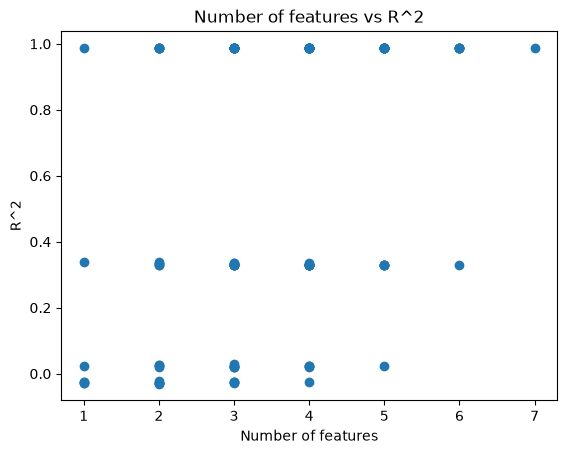

In [529]:
x_scatter = []
y_scatter = []

features = list(phase6_train_X.columns)
max_R_2 = -1
max_features = set()
for i in range(1, 8):
  features_subsets = findsubsets(features, i)
  for subset in features_subsets:
    phase6_train_X_subset = phase6_train_X.drop(columns= phase6_train_X.columns.difference(subset))
    subset_regression = linear_model.LinearRegression()
    R_2 = sum(cross_val_score(subset_regression, phase6_train_X_subset, phase6_train_Y, scoring='r2'))/5
    x_scatter.append(i)
    y_scatter.append(R_2)
    if(R_2 > max_R_2):
      max_R_2 = R_2
      max_features = subset

plt.title("Number of features vs R^2")
plt.xlabel("Number of features")
plt.ylabel("R^2")
plt.scatter(x_scatter, y_scatter)
print("Max R^2:", max_R_2)
print("Features:", max_features)
plt.savefig('../figures/graph17.png')

So the best set of features to work on a linear regression using the method of least squares is nodes, edges, inner radius, and outer radius.

So now we will train an Ridge regression model to find the prefect alpha value to make a Ridge  linear regression.

Max R^2: 0.9882916106230356
Features: ('nodes', 'edges', 'inner radius', 'minimum distance', 'outer - inner radius')


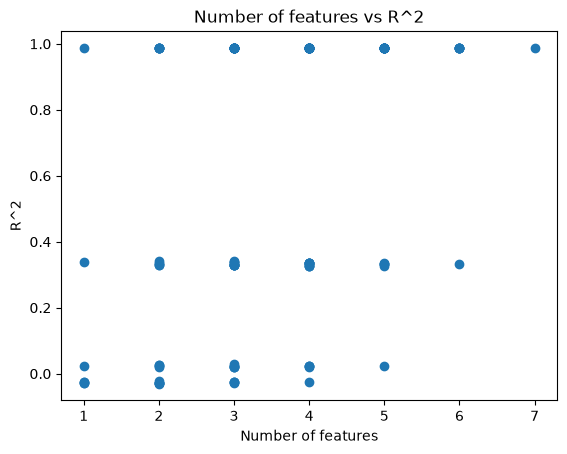

In [530]:
x_scatter = []
y_scatter = []

features = list(phase6_train_X_normalized.columns)
max_R_2 = -1
max_features = set()
for i in range(1, 8):
  features_subsets = findsubsets(features, i)
  for subset in features_subsets:
    phase6_train_X_normalized_subset = phase6_train_X_normalized.drop(columns= phase6_train_X_normalized.columns.difference(subset))
    subset_regression = linear_model.LinearRegression()
    R_2 = sum(cross_val_score(subset_regression, phase6_train_X_normalized_subset, phase6_train_Y_normalized, scoring='r2'))/5
    x_scatter.append(i)
    y_scatter.append(R_2)
    if(R_2 > max_R_2):
      max_R_2 = R_2
      max_features = subset

plt.title("Number of features vs R^2")
plt.xlabel("Number of features")
plt.ylabel("R^2")
plt.scatter(x_scatter, y_scatter)
print("Max R^2:", max_R_2)
print("Features:", max_features)
plt.savefig('../figures/graph18.png')

Max R^2: 0.98665624372438
Alpha: 10.985411419875584


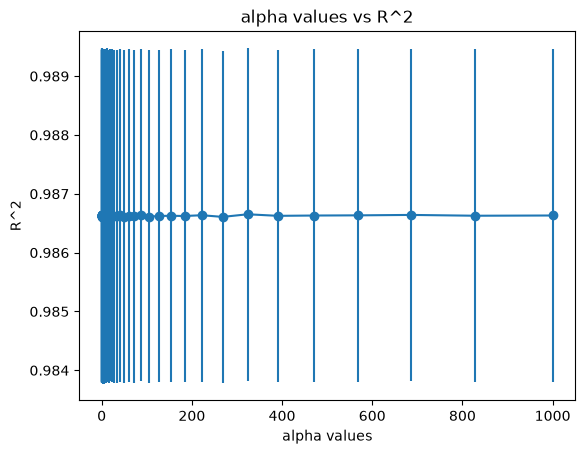

In [531]:
x_scatter = []
y_scatter = []
all_R_2_values = []

max_R_2 = -1
max_a_ridge = 0
a_values = np.logspace(-1,3)
for a in a_values:
  ridge_train = linear_model.Ridge(alpha=a, solver='sag')
  R_2_values = cross_val_score(ridge_train, phase6_train_X, phase6_train_Y, scoring='r2')
  R_2 = sum(R_2_values)/len(R_2_values)
  x_scatter.append(a)
  y_scatter.append(R_2)
  all_R_2_values.extend(R_2_values)
  if(R_2 > max_R_2):
    max_R_2 = R_2
    max_a_ridge = a


plt.title("alpha values vs R^2")
plt.xlabel("alpha values")
plt.ylabel("R^2")
plt.scatter(x_scatter, y_scatter)
plt.errorbar(a_values, y_scatter, yerr=np.std(all_R_2_values), xerr = 0)
print("Max R^2:", max_R_2)
print("Alpha:", max_a_ridge)
plt.savefig('../figures/graph19.png')

Max R^2: 0.9882431980891188
Alpha: 2.0235896477251565


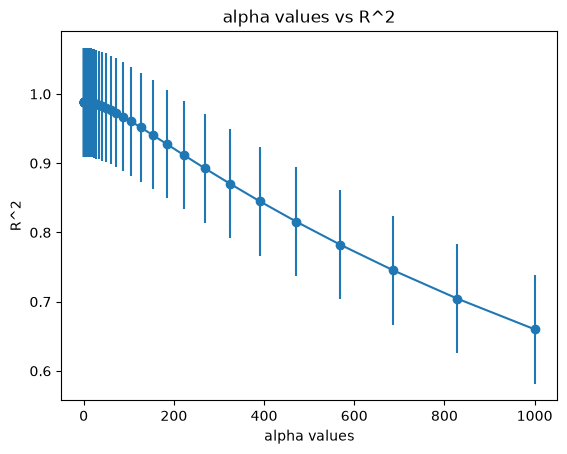

In [532]:
x_scatter = []
y_scatter = []
all_R_2_values = []

max_R_2_normalized = -1
max_a_ridge_normalized = 0
a_values = np.logspace(-1,3)
for a in a_values:
  ridge_train = linear_model.Ridge(alpha=a, solver='sag')
  R_2_values = cross_val_score(ridge_train, phase6_train_X_normalized, phase6_train_Y_normalized, scoring='r2')
  R_2 = sum(R_2_values)/len(R_2_values)
  x_scatter.append(a)
  y_scatter.append(R_2)
  all_R_2_values.extend(R_2_values)
  if(R_2 > max_R_2_normalized):
    max_R_2_normalized = R_2
    max_a_ridge_normalized = a


plt.title("alpha values vs R^2")
plt.xlabel("alpha values")
plt.ylabel("R^2")
plt.scatter(x_scatter, y_scatter)
plt.errorbar(a_values, y_scatter, yerr=np.std(all_R_2_values), xerr = 0)
print("Max R^2:", max_R_2_normalized)
print("Alpha:", max_a_ridge_normalized)
plt.savefig('../figures/graph20.png')

For the Final linear regression we will train it using LASSO by getting the best alpha value for LASSO.



Min mean standard error: 2248535694.8669443
Alpha: 13107.515074419907


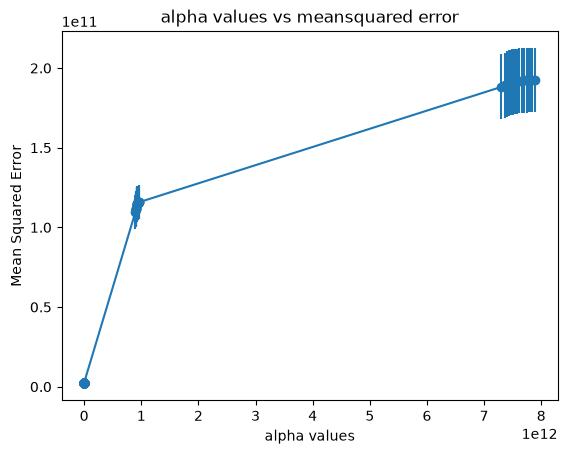

In [533]:
lasso_cv_train = linear_model.LassoLarsCV(cv=20)
lasso_cv_train.fit(phase6_train_X, phase6_train_Y)
a_values = lasso_cv_train.cv_alphas_
mean_squared_values = lasso_cv_train.mse_path_
y_scatter = []
yerr_scatter = []

min_mean_error = np.inf
best_alpha = None
for i in range(a_values.size):
    mean_error = np.mean(mean_squared_values[i])
    std_err = np.std(mean_squared_values[i]) / np.sqrt(20)

    y_scatter.append(mean_error)
    yerr_scatter.append(std_err)

    if mean_error < min_mean_error:
        min_mean_error = mean_error
        best_alpha = a_values[i]

plt.title("alpha values vs meansquared error")
plt.xlabel("alpha values")
plt.ylabel("Mean Squared Error")
plt.scatter(a_values, y_scatter)
plt.errorbar(a_values, y_scatter, yerr=yerr_scatter, xerr=0)
print("Min mean standard error:", min_mean_error)
print("Alpha:", best_alpha)
plt.savefig('../figures/graph21.png')

Min mean standard error: 0.011722631647607238
Alpha: 0.0010902679100282477


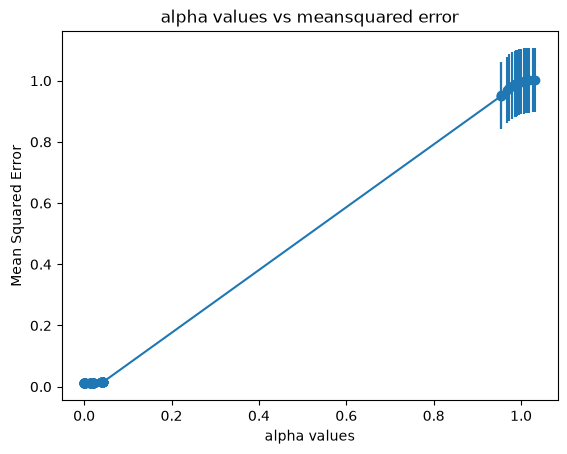

In [534]:
lasso_cv_train = linear_model.LassoLarsCV(cv=20)
lasso_cv_train.fit(phase6_train_X_normalized, phase6_train_Y_normalized)
a_values = lasso_cv_train.cv_alphas_
mean_squared_values = lasso_cv_train.mse_path_
y_scatter = []
yerr_scatter = []

min_mean_error_normalized = np.inf
best_alpha_normalized = None
for i in range(a_values.size):
    mean_error = np.mean(mean_squared_values[i])
    std_err = np.std(mean_squared_values[i]) / np.sqrt(20)

    y_scatter.append(mean_error)
    yerr_scatter.append(std_err)

    if mean_error < min_mean_error_normalized:
        min_mean_error_normalized = mean_error
        best_alpha_normalized = a_values[i]

plt.title("alpha values vs meansquared error")
plt.xlabel("alpha values")
plt.ylabel("Mean Squared Error")
plt.scatter(a_values, y_scatter)
plt.errorbar(a_values, y_scatter, yerr=yerr_scatter, xerr=0)
print("Min mean standard error:", min_mean_error_normalized)
print("Alpha:", best_alpha_normalized)
plt.savefig('../figures/graph22.png')

Now that we got the best subset of features for the LinearRegression, and alpha values for the Ridge and LASSO regressions, we can test them with the test data.

Testing the LinearRegression with the best subset and returning the R^2 value.

In [535]:
regression = linear_model.LinearRegression()
regression.fit(phase6_train_X_subset, phase6_train_Y)
R_2_regression = sum(cross_val_score(regression, phase6_train_X_subset, phase6_train_Y, scoring='r2'))/5
mse_regression = sum(cross_val_score(regression, phase6_train_X_subset, phase6_train_Y, scoring='neg_mean_squared_error'))/5
print("R^2:", R_2_regression)
print("MSE:", -mse_regression)

R^2: 0.9882823918578522
MSE: 2237888026.1524496


In [536]:
regression_normalized = linear_model.LinearRegression()
regression_normalized.fit(phase6_train_X_normalized_subset, phase6_train_Y_normalized)
R_2_regression_normalized = sum(cross_val_score(regression_normalized, phase6_train_X_normalized_subset, phase6_train_Y_normalized, scoring='r2'))/5
mse_regression_normalized = sum(cross_val_score(regression_normalized, phase6_train_X_normalized_subset, phase6_train_Y_normalized, scoring='neg_mean_squared_error'))/5

print("R^2:", R_2_regression_normalized)
print("MSE:", -mse_regression_normalized)

R^2: 0.988219136701993
MSE: 0.011693042107379528


In [537]:
R_2_regression_test = regression.score(phase6_test_X[phase6_train_X_subset.columns], phase6_test_Y)
mse_regression_test = np.mean((regression.predict(phase6_test_X[phase6_train_X_subset.columns]) - phase6_test_Y) ** 2)

print('R^2 on test set:', R_2_regression_test)
print("mean squared error on test set:", mse_regression_test)

R^2 on test set: 0.9927406476683946
mean squared error on test set: 1742562415.5697339


In [538]:
R_2_regression_normalized_test = regression_normalized.score(phase6_test_X_normalized[phase6_train_X_normalized_subset.columns], phase6_test_Y_normalized)
mse_regression_normalized_test = np.mean((regression_normalized.predict(phase6_test_X_normalized[phase6_train_X_normalized_subset.columns]) - phase6_test_Y_normalized) ** 2)

print('R^2 on normalized test set:', R_2_regression_normalized_test)
print("mean squared error on normalized test set:", mse_regression_normalized_test)

R^2 on normalized test set: 0.9927807652352284
mean squared error on normalized test set: 0.009023497304068125


Testing Ridge Regression with alpha of 0.1

In [539]:
ridge = linear_model.Ridge(alpha=max_a_ridge, solver='sag')
R_2_ridge = sum(cross_val_score(ridge, phase6_train_X, phase6_train_Y, scoring='r2'))/5
mse_ridge = sum(cross_val_score(ridge, phase6_train_X, phase6_train_Y, scoring='neg_mean_squared_error'))/5
ridge.fit(phase6_train_X, phase6_train_Y)

print('R^2:', R_2_ridge)
print("mean squared error:", -mse_ridge)

R^2: 0.9866075945534728
mean squared error: 2599303895.4699874


In [540]:
ridge_normalized = linear_model.Ridge(alpha=max_a_ridge_normalized, solver='sag')
R_2_ridge_normalized = sum(cross_val_score(ridge_normalized, phase6_train_X_normalized, phase6_train_Y_normalized, scoring='r2'))/5
mse_ridge_normalized = sum(cross_val_score(ridge_normalized, phase6_train_X_normalized, phase6_train_Y_normalized, scoring='neg_mean_squared_error'))/5
ridge_normalized.fit(phase6_train_X_normalized, phase6_train_Y_normalized)  

print('R^2:', R_2_ridge_normalized)
print("mean squared error:", -mse_ridge_normalized)

R^2: 0.9882404146083031
mean squared error: 0.0117300404439302


In [541]:
R_2_ridge_test = ridge.score(phase6_test_X, phase6_test_Y)
mse_ridge_test = np.mean((ridge.predict(phase6_test_X) - phase6_test_Y) ** 2)

print('R^2 on test set:', R_2_ridge_test)
print("mean squared error on test set:", mse_ridge_test)

R^2 on test set: 0.992288016663671
mean squared error on test set: 1851213675.4788492


In [542]:
R_2_ridge_normalized_test = ridge_normalized.score(phase6_test_X_normalized, phase6_test_Y_normalized)
mse_ridge_normalized_test = np.mean((ridge_normalized.predict(phase6_test_X_normalized) - phase6_test_Y_normalized) ** 2)

print('R^2 on normalized test set:', R_2_ridge_normalized_test)
print("mean squared error on normalized test set:", mse_ridge_normalized_test)

R^2 on normalized test set: 0.9925157784573703
mean squared error on normalized test set: 0.009354710729524825


Testing LASSO with alpha of $7.11 \times 10^{-5}$

In [543]:
lasso = linear_model.Lasso(alpha=best_alpha, max_iter=10000)
R_2_lasso = sum(cross_val_score(lasso, phase6_train_X, phase6_train_Y, scoring='r2'))/5
mse_lasso = sum(cross_val_score(lasso, phase6_train_X, phase6_train_Y, scoring='neg_mean_squared_error'))/5
lasso.fit(phase6_train_X, phase6_train_Y)

print('R^2:', R_2_lasso)
print("mean squared error:", -mse_lasso)

R^2: 0.9882790148534282
mean squared error: 2238365070.611211


In [544]:
lasso_normalized = linear_model.Lasso(alpha=best_alpha_normalized, max_iter=10000)
R_2_lasso_normalized = sum(cross_val_score(lasso_normalized, phase6_train_X_normalized, phase6_train_Y_normalized, scoring='r2'))/5
mse_lasso_normalized = sum(cross_val_score(lasso_normalized, phase6_train_X_normalized, phase6_train_Y_normalized, scoring='neg_mean_squared_error'))/5
lasso_normalized.fit(phase6_train_X_normalized, phase6_train_Y_normalized)

print('R^2:', R_2_lasso_normalized)
print("mean squared error:", -mse_lasso_normalized)

R^2: 0.9882931243717812
mean squared error: 0.01167409167325607


In [545]:
R_2_lasso_test = lasso.score(phase6_test_X, phase6_test_Y)
mse_lasso_test = np.mean((lasso.predict(phase6_test_X) - phase6_test_Y) ** 2)

print('R^2 on test set:', R_2_lasso_test)
print("mean squared error on test set:", mse_lasso_test)

R^2 on test set: 0.9927423989145335
mean squared error on test set: 1742142039.8168218


In [546]:
R_2_lasso_normalized_test = lasso_normalized.score(phase6_test_X_normalized, phase6_test_Y_normalized)
mse_lasso_normalized_test = np.mean((lasso_normalized.predict(phase6_test_X_normalized) - phase6_test_Y_normalized) ** 2)

print('R^2 on normalized test set:', R_2_lasso_normalized_test)
print("mean squared error on normalized test set:", mse_lasso_normalized_test)

R^2 on normalized test set: 0.9927153497056141
mean squared error on normalized test set: 0.009105261767248926


Now based on the R^2 and mean squared error of  each of the three regressions we can see the LinearRegression with the subset of nodes, edges, inner radius, and maximum distance just  slightly edges out the Ridge model at 0.1 with both beating the LASSO regression.

Now we will show the coeffiecients for each feature for each regression.

In [547]:
regression_weights = []
sub = 0
for i in range(len(features)):
  if(features[i] in max_features):
    regression_weights.append(regression.coef_[i - sub])
  else:
    sub += 1
    regression_weights.append(0)

features_weight_dict = {'Regression': regression_weights,
                        'Ridge': ridge.coef_,
                        'Lasso': lasso.coef_}
features_weights = pd.DataFrame(data=features_weight_dict, index=features)
print(features_weights)

                      Regression         Ridge      Lasso
nodes                   0.000125  1.861230e-04   0.000125
edges                   0.129049  1.289156e-01   0.129048
inner radius           32.053097  2.432531e-05  40.819837
outer radius            0.000000  9.769517e-06  -0.000000
minimum distance        8.825084 -3.149382e-09   0.000000
maximum distance        0.000000  3.653470e-07  -0.000000
outer - inner radius   -0.015146 -1.455579e-05 -14.355819


In [548]:
regression_weights = []
sub = 0
for i in range(len(features)):
  if(features[i] in max_features):
    regression_weights.append(regression_normalized.coef_[i - sub])
  else:
    sub += 1
    regression_weights.append(0)

features_weight_dict = {'Regression_Normalized': regression_weights,
                        'Ridge_Normalized': ridge_normalized.coef_,
                        'Lasso_Normalized': lasso_normalized.coef_}
features_weights = pd.DataFrame(data=features_weight_dict, index=features)
print(features_weights)

                      Regression_Normalized  Ridge_Normalized  \
nodes                              0.008699          0.011450   
edges                              0.987309          0.982772   
inner radius                       0.040628          0.040079   
outer radius                       0.000000          0.005112   
minimum distance                   0.005638          0.004126   
maximum distance                   0.000000         -0.006485   
outer - inner radius               0.004478         -0.021128   

                      Lasso_Normalized  
nodes                         0.007574  
edges                         0.986204  
inner radius                  0.038512  
outer radius                 -0.000000  
minimum distance              0.002170  
maximum distance             -0.000000  
outer - inner radius         -0.020294  
